# 🎗️ Breast Cancer Prediction
### Disease Prediction from Medical Data — Model 3 of 3

| Property | Detail |
|----------|--------|
| **Dataset** | Breast Cancer Wisconsin (UCI, 1000 samples, 30 features) |
| **Target** | `diagnosis` — 0 = Benign, 1 = Malignant |
| **Algorithms** | Logistic Regression · SVM · Random Forest · XGBoost |
| **Platform** | Google Colab |

**Feature groups:** mean, standard error, and worst values for radius, texture, perimeter, area, smoothness, compactness, concavity, concave points, symmetry, fractal dimension.

> ⚠️ Run **Cell 1 first** — it installs packages and imports everything.

## 📦 Cell 1 — Install & Import

In [2]:
import sys, subprocess
subprocess.check_call([
    sys.executable, '-m', 'pip', 'install',
    'xgboost', 'scikit-learn', 'pandas', 'numpy',
    'matplotlib', 'seaborn',
    '--quiet'
])

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, precision_recall_curve, f1_score
)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

np.random.seed(42)
print('✅ All imports successful!')

✅ All imports successful!


## ☁️ Cell 2 — Load Dataset (Colab)

In [3]:
# ── Option A: Upload directly ─────────────────────────────────────────────────
from google.colab import files
uploaded = files.upload()   # select breast_cancer_dataset.csv
CSV_PATH = 'breast_cancer_dataset.csv'

# ── Option B: Google Drive ────────────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')
CSV_PATH = '/content/drive/MyDrive/breast_cancer_dataset.csv'

CSV_PATH    = 'breast_cancer_dataset.csv'
TARGET_COL  = 'diagnosis'
CLASS_NAMES = ['Benign', 'Malignant']

df = pd.read_csv(CSV_PATH)
print(f'Dataset shape : {df.shape}')
print(f'Target counts :')
print(df[TARGET_COL].value_counts().rename({0:'Benign',1:'Malignant'}).to_string())
print(f'\nFeature groups:')
print('  _mean   :', [c for c in df.columns if c.endswith('_mean')])
print('  _se     :', [c for c in df.columns if c.endswith('_se')])
print('  _worst  :', [c for c in df.columns if c.endswith('_worst')])
df.head()

Saving breast_cancer_dataset.csv to breast_cancer_dataset (1).csv
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset shape : (1000, 31)
Target counts :
diagnosis
Malignant    667
Benign       333

Feature groups:
  _mean   : ['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave_points_mean', 'symmetry_mean', 'fractal_dim_mean']
  _se     : ['radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave_points_se', 'symmetry_se', 'fractal_dim_se']
  _worst  : ['radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave_points_worst', 'symmetry_worst', 'fractal_dim_worst']


,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,fractal_dim_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dim_worst,diagnosis
0,10.0536,10.9575,94.49,601.17,0.0936,0.0893,0.1138,0.0300,0.1663,0.0581,...,19.7762,87.66,402.94,0.0978,0.1432,0.1460,0.1365,0.2979,0.0588,1
1,13.4449,19.4369,65.91,580.38,0.1087,0.0397,0.0943,0.0000,0.1429,0.0548,...,25.8104,79.45,508.94,0.1517,0.0234,0.2154,0.0824,0.2674,0.0751,1
2,21.7698,22.0721,158.56,1224.09,0.0853,0.1220,0.1788,0.0873,0.1944,0.0698,...,30.1109,154.99,2063.71,0.1568,0.4249,0.6468,0.0435,0.2256,0.0894,0
3,14.4713,10.9748,92.05,410.30,0.0825,0.0503,0.1457,0.0499,0.1646,0.0598,...,24.9954,74.46,579.40,0.1170,0.2344,0.0000,0.0854,0.2501,0.0553,1
4,16.0722,19.3381,63.48,275.13,0.0996,0.1278,0.0246,0.0373,0.1738,0.0633,...,10.8565,72.15,341.40,0.1456,0.1194,0.0887,0.1106,0.3520,0.0570,1


## 🔍 Cell 3 — Exploratory Data Analysis

In [4]:
print('=== Statistical Summary (mean features) ===')
mean_cols = [c for c in df.columns if c.endswith('_mean')]
df[mean_cols + [TARGET_COL]].describe().round(3)

=== Statistical Summary (mean features) ===


,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,fractal_dim_mean,diagnosis
count,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000
mean,13.817,19.164,90.278,625.885,0.095,0.102,0.087,0.047,0.179,0.063,0.667
std,3.461,4.376,23.704,317.800,0.014,0.052,0.077,0.037,0.029,0.007,0.472
min,5.158,6.039,35.910,51.750,0.052,0.000,0.000,0.000,0.083,0.041,0.000
25%,11.322,16.214,73.867,415.492,0.086,0.064,0.028,0.021,0.160,0.058,0.000
50%,13.032,18.999,84.495,528.160,0.096,0.094,0.069,0.037,0.179,0.063,1.000
75%,15.634,22.137,102.460,740.548,0.105,0.130,0.127,0.064,0.198,0.067,1.000
max,26.319,32.345,173.840,2096.090,0.141,0.341,0.426,0.188,0.264,0.086,1.000


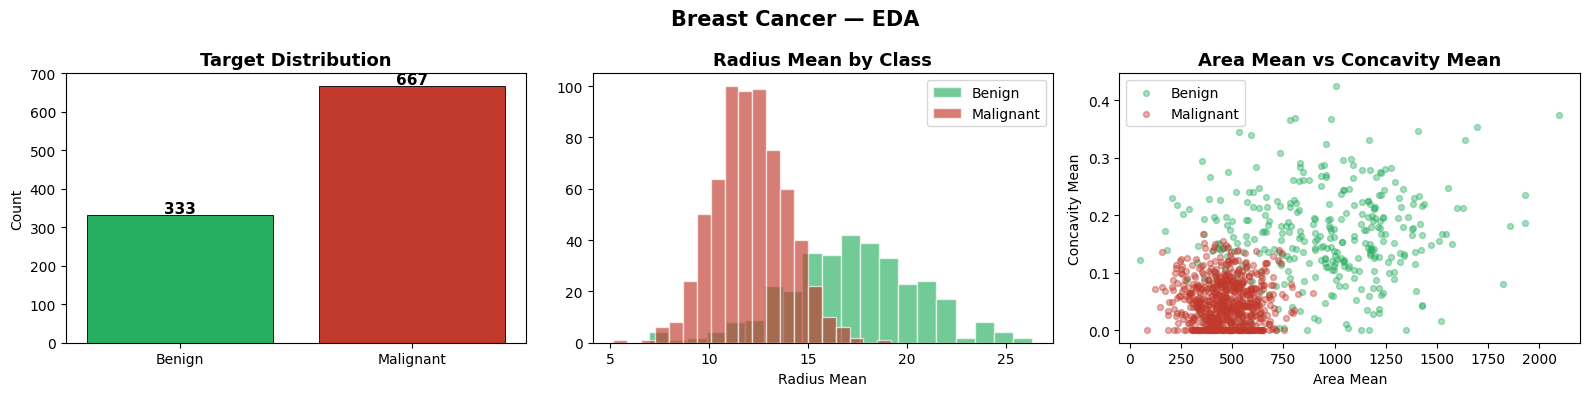

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Target distribution
counts = df[TARGET_COL].value_counts().sort_index()
axes[0].bar(CLASS_NAMES, counts.values, color=['#27ae60','#c0392b'],
            edgecolor='black', linewidth=0.6)
axes[0].set_title('Target Distribution', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v+5, str(v), ha='center', fontsize=11, fontweight='bold')

# Radius mean by class
for cls, color, label in [(0,'#27ae60','Benign'),(1,'#c0392b','Malignant')]:
    axes[1].hist(df[df[TARGET_COL]==cls]['radius_mean'], bins=20, alpha=0.65,
                 color=color, label=label, edgecolor='white')
axes[1].set_title('Radius Mean by Class', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Radius Mean'); axes[1].legend()

# Concavity mean vs Area mean
for cls, color, label in [(0,'#27ae60','Benign'),(1,'#c0392b','Malignant')]:
    sub = df[df[TARGET_COL]==cls]
    axes[2].scatter(sub['area_mean'], sub['concavity_mean'],
                    alpha=0.4, c=color, label=label, s=18)
axes[2].set_title('Area Mean vs Concavity Mean', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Area Mean'); axes[2].set_ylabel('Concavity Mean')
axes[2].legend()

plt.suptitle('Breast Cancer — EDA', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

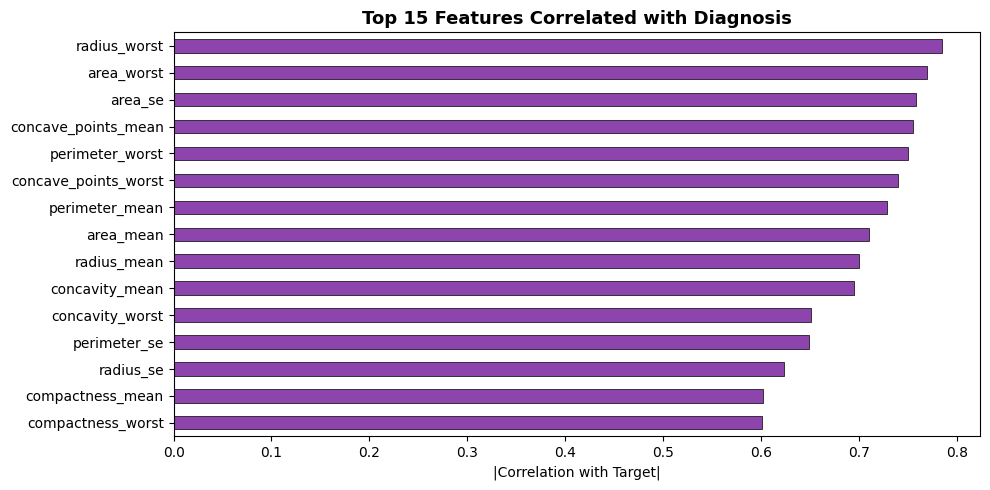

Top 15 features:
radius_worst            0.784516
area_worst              0.769994
area_se                 0.758558
concave_points_mean     0.755110
perimeter_worst         0.749865
concave_points_worst    0.739505
perimeter_mean          0.729085
area_mean               0.710513
radius_mean             0.700601
concavity_mean          0.694572
concavity_worst         0.650707
perimeter_se            0.649040
radius_se               0.623755
compactness_mean        0.602525
compactness_worst       0.600651


In [6]:
# Top correlated features with target
corr_with_target = df.corr()[TARGET_COL].drop(TARGET_COL).abs().sort_values(ascending=False)
top15 = corr_with_target.head(15)

fig, ax = plt.subplots(figsize=(10, 5))
top15.sort_values().plot(kind='barh', ax=ax, color='#8e44ad',
                          edgecolor='black', linewidth=0.5)
ax.set_title('Top 15 Features Correlated with Diagnosis',
             fontsize=13, fontweight='bold')
ax.set_xlabel('|Correlation with Target|')
plt.tight_layout()
plt.show()

print('Top 15 features:')
print(top15.to_string())

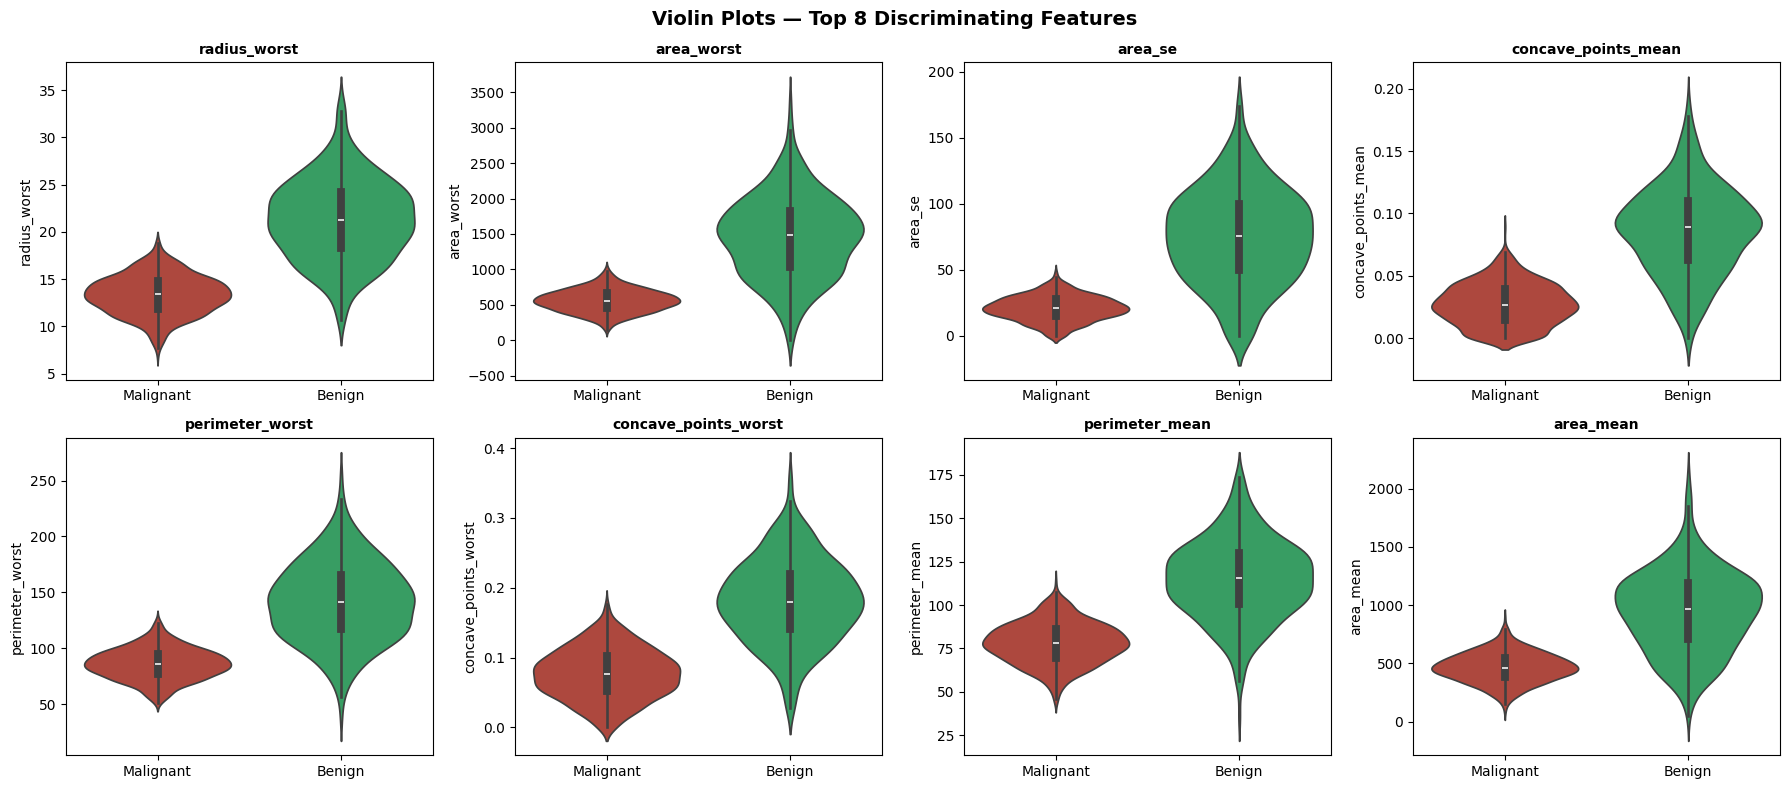

In [7]:
# Violin plots for top 8 mean features
top8_feats = corr_with_target.head(8).index.tolist()
plot_df    = df[top8_feats + [TARGET_COL]].copy()
plot_df[TARGET_COL] = plot_df[TARGET_COL].map({0:'Benign', 1:'Malignant'})

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, feat in enumerate(top8_feats):
    sns.violinplot(data=plot_df, x=TARGET_COL, y=feat,
                   palette={'Benign':'#27ae60','Malignant':'#c0392b'},
                   ax=axes[i], inner='box')
    axes[i].set_title(feat, fontsize=10, fontweight='bold')
    axes[i].set_xlabel('')

plt.suptitle('Violin Plots — Top 8 Discriminating Features',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

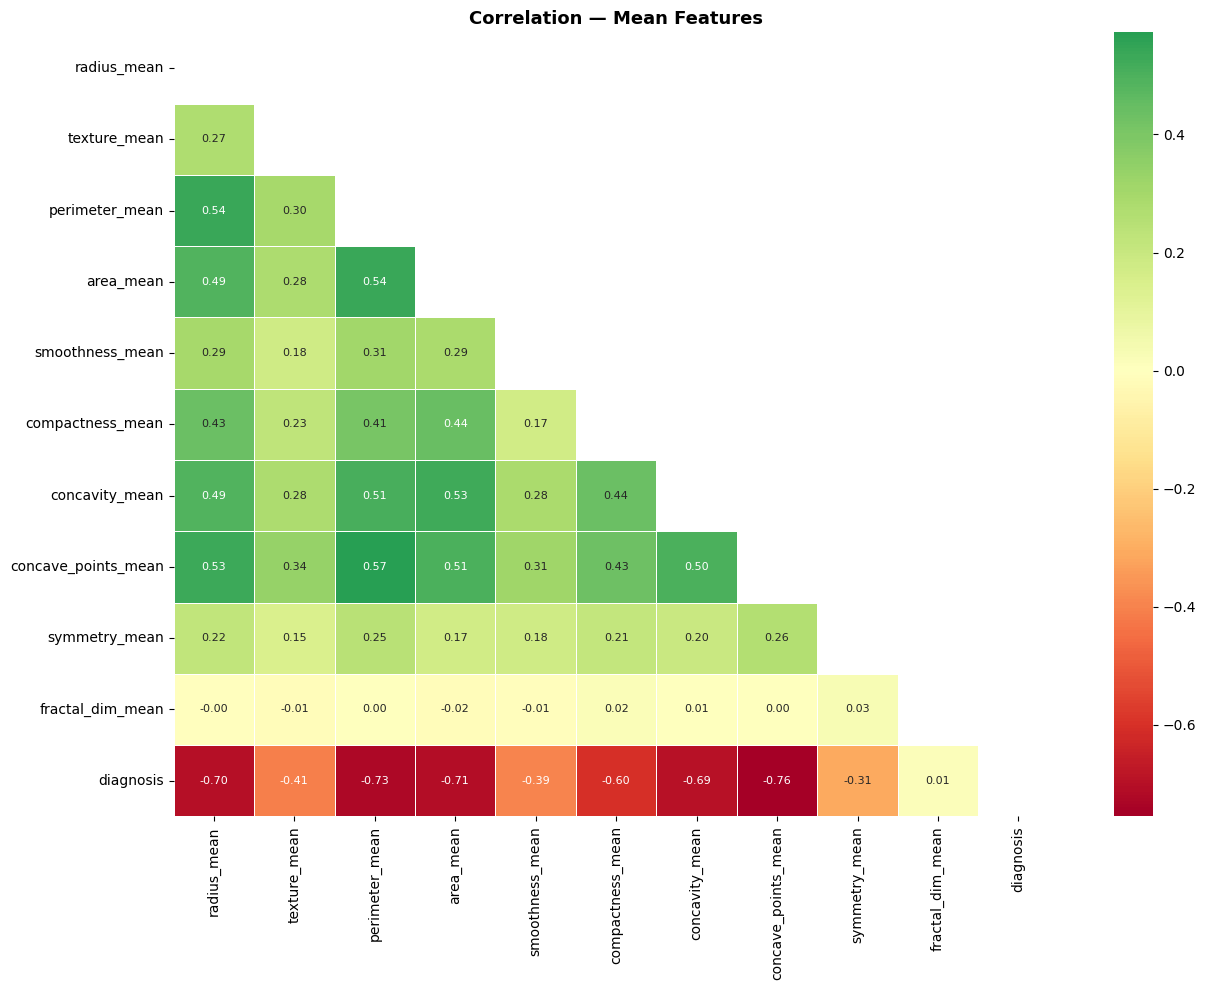

In [8]:
# Correlation heatmap (mean features only — cleaner view)
mean_cols = [c for c in df.columns if c.endswith('_mean')] + [TARGET_COL]
fig, ax   = plt.subplots(figsize=(13, 10))
corr      = df[mean_cols].corr()
mask      = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.5, ax=ax, annot_kws={'size':8})
ax.set_title('Correlation — Mean Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## ⚙️ Cell 4 — Preprocessing & PCA Visualisation

Train : (800, 30)  |  Test : (200, 30)


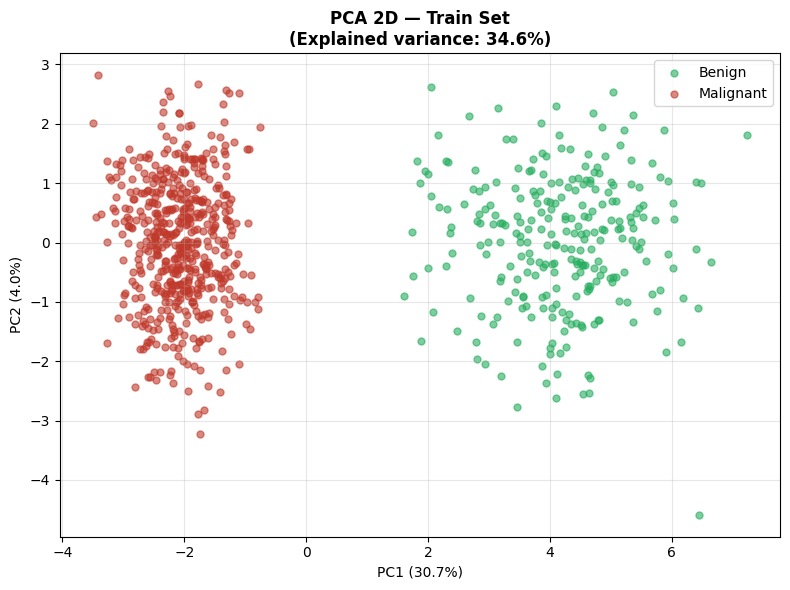

In [9]:
X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]
feature_names = X.columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

scaler    = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f'Train : {X_train_s.shape}  |  Test : {X_test_s.shape}')

# PCA 2D visualisation
pca    = PCA(n_components=2, random_state=42)
X_pca  = pca.fit_transform(X_train_s)

fig, ax = plt.subplots(figsize=(8, 6))
for cls, color, label in [(0,'#27ae60','Benign'),(1,'#c0392b','Malignant')]:
    mask = y_train.values == cls
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=color, label=label, alpha=0.6, s=25)
ax.set_title(f'PCA 2D — Train Set\n(Explained variance: '
             f'{pca.explained_variance_ratio_.sum()*100:.1f}%)',
             fontsize=12, fontweight='bold')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 🤖 Cell 5 — Train All Four Models

In [10]:
models_dict = {
    'Logistic Regression': LogisticRegression(max_iter=2000, random_state=42, C=0.5),
    'SVM':                 SVC(kernel='rbf', probability=True, random_state=42, C=1.0),
    'Random Forest':       RandomForestClassifier(n_estimators=200, random_state=42,
                                                   max_depth=10, min_samples_split=4),
    'XGBoost':             XGBClassifier(n_estimators=200, learning_rate=0.1,
                                         max_depth=5, use_label_encoder=False,
                                         eval_metric='logloss', random_state=42,
                                         verbosity=0)
}

results = {}
cv      = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, clf in models_dict.items():
    clf.fit(X_train_s, y_train)
    y_pred  = clf.predict(X_test_s)
    y_proba = clf.predict_proba(X_test_s)[:, 1]
    cv_acc  = cross_val_score(clf, X_train_s, y_train, cv=cv,
                               scoring='accuracy').mean()
    results[name] = {
        'model'   : clf,
        'y_pred'  : y_pred,
        'y_proba' : y_proba,
        'accuracy': accuracy_score(y_test, y_pred),
        'roc_auc' : roc_auc_score(y_test, y_proba),
        'f1'      : f1_score(y_test, y_pred),
        'cv_acc'  : cv_acc
    }
    print(f'{name:22s} | Acc={results[name]["accuracy"]:.4f}  '
          f'AUC={results[name]["roc_auc"]:.4f}  '
          f'F1={results[name]["f1"]:.4f}  '
          f'CV={cv_acc:.4f}')

Logistic Regression    | Acc=1.0000  AUC=1.0000  F1=1.0000  CV=1.0000
SVM                    | Acc=1.0000  AUC=1.0000  F1=1.0000  CV=1.0000
Random Forest          | Acc=1.0000  AUC=1.0000  F1=1.0000  CV=1.0000
XGBoost                | Acc=1.0000  AUC=1.0000  F1=1.0000  CV=0.9988


## 📊 Cell 6 — Model Comparison

=== Model Comparison ===
                     Accuracy  ROC-AUC  F1 Score  CV Acc
Logistic Regression       1.0      1.0       1.0  1.0000
SVM                       1.0      1.0       1.0  1.0000
Random Forest             1.0      1.0       1.0  1.0000
XGBoost                   1.0      1.0       1.0  0.9988


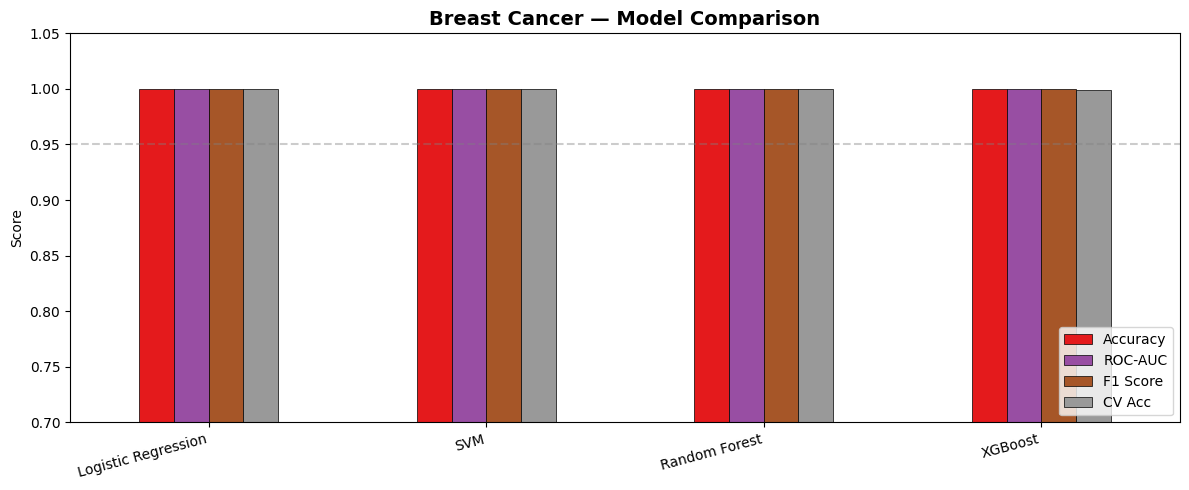

In [11]:
metrics_df = pd.DataFrame({
    name: {
        'Accuracy': r['accuracy'],
        'ROC-AUC' : r['roc_auc'],
        'F1 Score': r['f1'],
        'CV Acc'  : r['cv_acc']
    } for name, r in results.items()
}).T.round(4)

print('=== Model Comparison ===')
print(metrics_df.to_string())

fig, ax = plt.subplots(figsize=(12, 5))
metrics_df[['Accuracy','ROC-AUC','F1 Score','CV Acc']].plot(
    kind='bar', ax=ax, colormap='Set1', edgecolor='black', linewidth=0.5
)
ax.set_title('Breast Cancer — Model Comparison', fontsize=14, fontweight='bold')
ax.set_ylabel('Score'); ax.set_ylim([0.7, 1.05])
ax.set_xticklabels(ax.get_xticklabels(), rotation=15, ha='right')
ax.axhline(y=0.95, color='gray', linestyle='--', alpha=0.4)
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('bc_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 📉 Cell 7 — Confusion Matrices

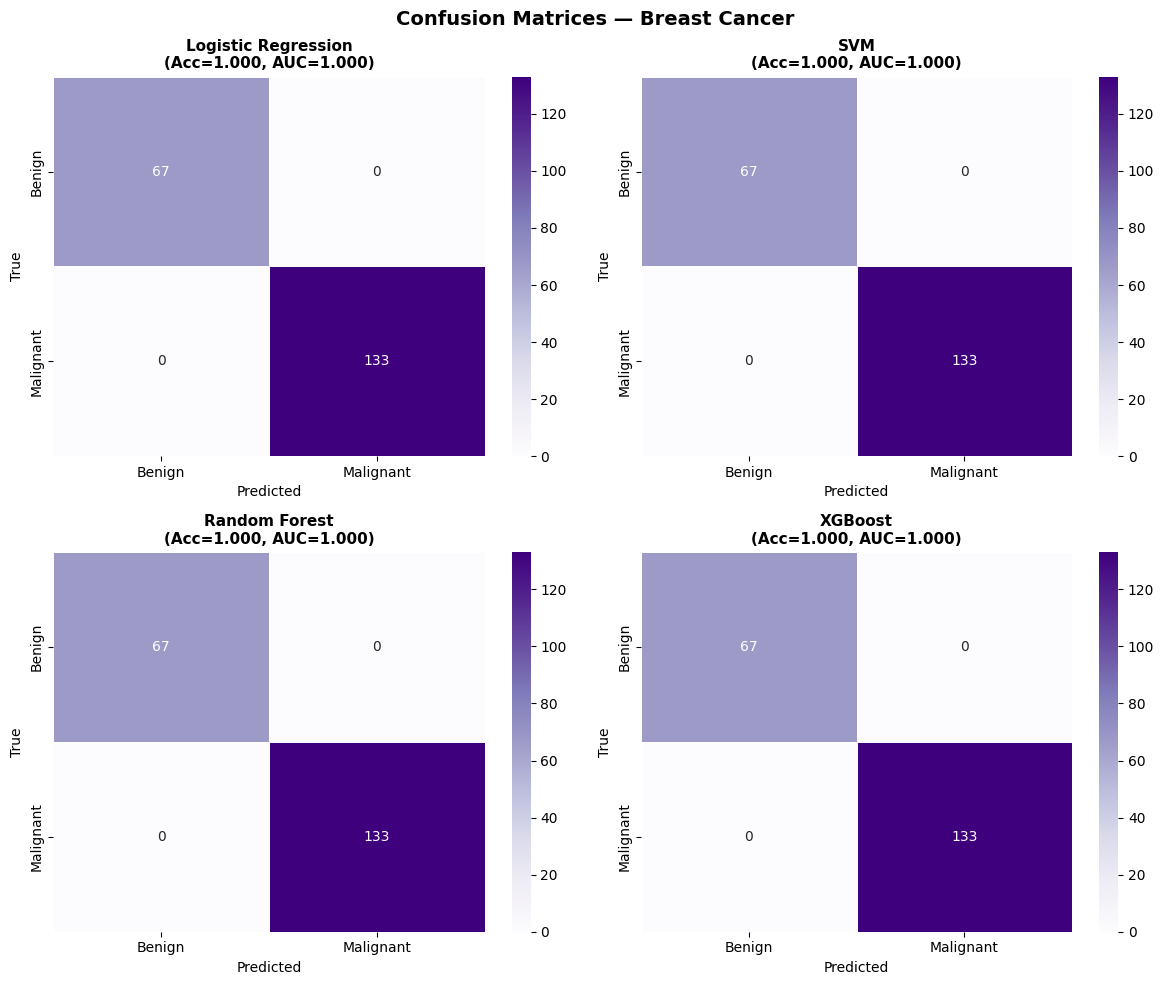

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, (name, r) in enumerate(results.items()):
    cm = confusion_matrix(y_test, r['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                linewidths=0.5, ax=axes[i])
    axes[i].set_title(f'{name}\n(Acc={r["accuracy"]:.3f}, AUC={r["roc_auc"]:.3f})',
                      fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Predicted'); axes[i].set_ylabel('True')

plt.suptitle('Confusion Matrices — Breast Cancer', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('bc_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

## 📈 Cell 8 — ROC & Precision-Recall Curves

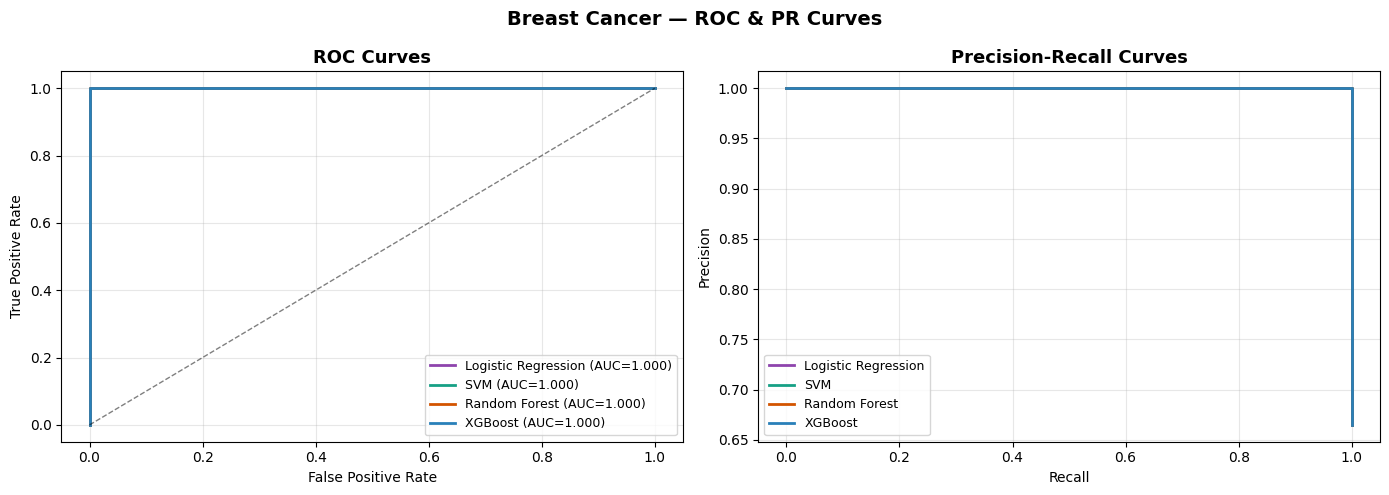

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#8e44ad','#16a085','#d35400','#2980b9']

for (name, r), color in zip(results.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, r['y_proba'])
    axes[0].plot(fpr, tpr, color=color, lw=2,
                 label=f'{name} (AUC={r["roc_auc"]:.3f})')
axes[0].plot([0,1],[0,1],'k--', lw=1, alpha=0.5)
axes[0].set_title('ROC Curves', fontsize=13, fontweight='bold')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend(fontsize=9); axes[0].grid(True, alpha=0.3)

for (name, r), color in zip(results.items(), colors):
    prec, rec, _ = precision_recall_curve(y_test, r['y_proba'])
    axes[1].plot(rec, prec, color=color, lw=2, label=name)
axes[1].set_title('Precision-Recall Curves', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].legend(fontsize=9); axes[1].grid(True, alpha=0.3)

plt.suptitle('Breast Cancer — ROC & PR Curves', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('bc_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 🌲 Cell 9 — Feature Importance (Top 15)

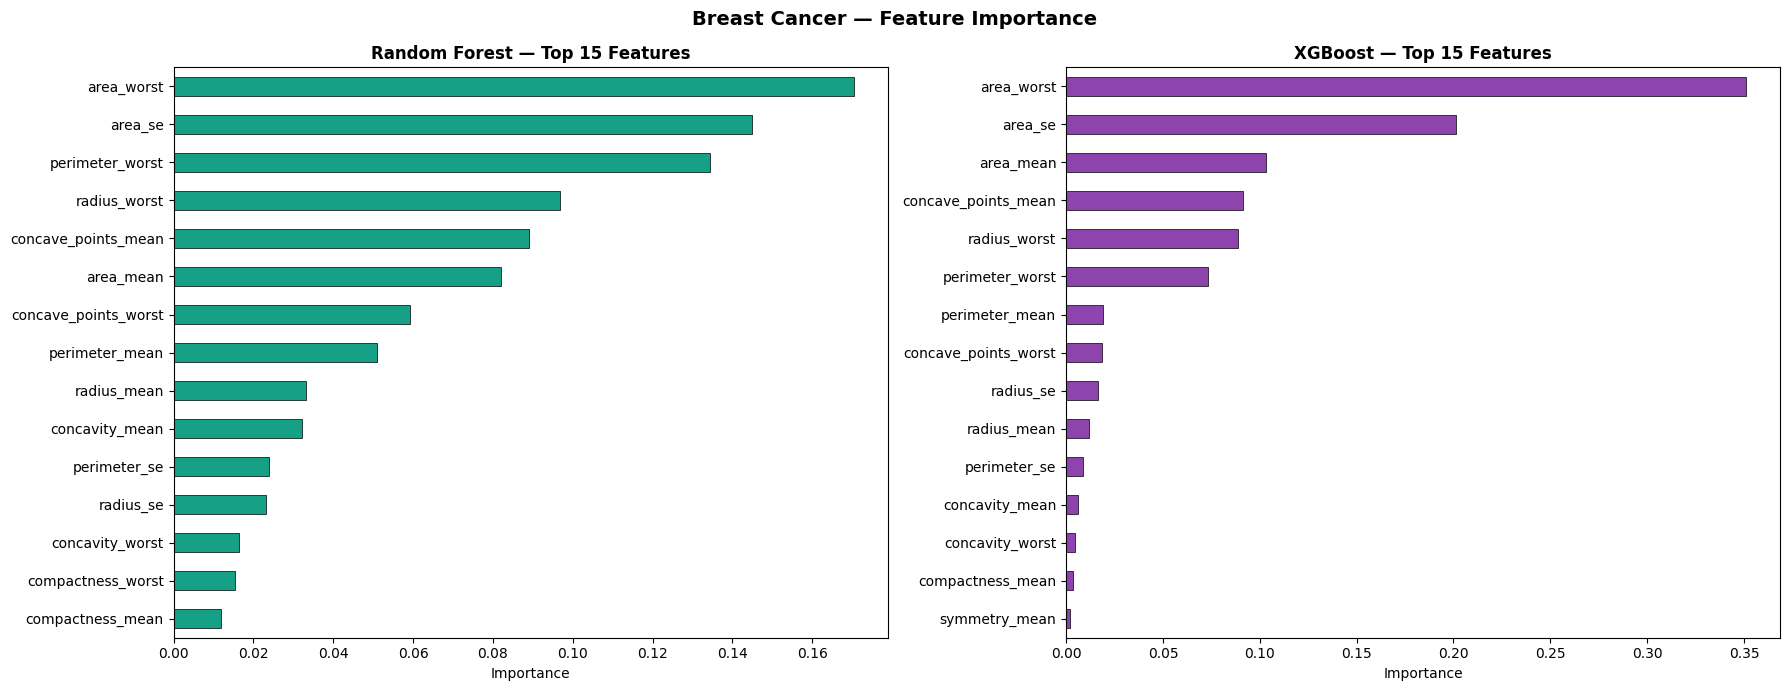

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Random Forest — top 15
rf_imp = pd.Series(
    results['Random Forest']['model'].feature_importances_,
    index=feature_names
).sort_values(ascending=False).head(15).sort_values(ascending=True)
rf_imp.plot(kind='barh', ax=axes[0], color='#16a085', edgecolor='black', linewidth=0.5)
axes[0].set_title('Random Forest — Top 15 Features', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Importance')

# XGBoost — top 15
xgb_imp = pd.Series(
    results['XGBoost']['model'].feature_importances_,
    index=feature_names
).sort_values(ascending=False).head(15).sort_values(ascending=True)
xgb_imp.plot(kind='barh', ax=axes[1], color='#8e44ad', edgecolor='black', linewidth=0.5)
axes[1].set_title('XGBoost — Top 15 Features', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Importance')

plt.suptitle('Breast Cancer — Feature Importance', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('bc_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## 📋 Cell 10 — Classification Reports

In [15]:
for name, r in results.items():
    print(f'\n{"="*55}')
    print(f'  {name}')
    print(f'{"="*55}')
    print(classification_report(y_test, r['y_pred'],
                                 target_names=CLASS_NAMES))


  Logistic Regression
              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00        67
   Malignant       1.00      1.00      1.00       133

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200


  SVM
              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00        67
   Malignant       1.00      1.00      1.00       133

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200


  Random Forest
              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00        67
   Malignant       1.00      1.00      1.00       133

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00    

## 🔮 Cell 11 — Predict on New Patient Data

In [16]:
best_model_name = max(results, key=lambda k: results[k]['roc_auc'])
best_model      = results[best_model_name]['model']
print(f'Best model (by ROC-AUC): {best_model_name}')

# Use mean values from the dataset as a sample patient
sample_row = X.mean().to_dict()
# Modify a few to simulate a potentially malignant profile
sample_row.update({
    'radius_mean': 18.0,
    'texture_mean': 22.0,
    'perimeter_mean': 120.0,
    'area_mean': 1000.0,
    'concavity_mean': 0.20,
    'concave_points_mean': 0.12
})

new_patient = pd.DataFrame([sample_row])
new_scaled  = scaler.transform(new_patient)
pred_class  = best_model.predict(new_scaled)[0]
pred_prob   = best_model.predict_proba(new_scaled)[0]

print(f'\nPrediction : {CLASS_NAMES[pred_class]}  (label={pred_class})')
print(f'Confidence : Benign={pred_prob[0]:.2%}  Malignant={pred_prob[1]:.2%}')

Best model (by ROC-AUC): Logistic Regression

Prediction : Benign  (label=0)
Confidence : Benign=92.86%  Malignant=7.14%


## ✅ Cell 12 — Summary

In [17]:
best = max(results, key=lambda k: results[k]['roc_auc'])
print('Breast Cancer Prediction — Results Summary')
print('='*55)
for name, r in results.items():
    star = ' ← BEST' if name == best else ''
    print(f'  {name:22s}  AUC={r["roc_auc"]:.4f}  Acc={r["accuracy"]:.4f}{star}')
print('='*55)
print(f'Best Model : {best}')
print(f'Best AUC   : {results[best]["roc_auc"]:.4f}')

Breast Cancer Prediction — Results Summary
  Logistic Regression     AUC=1.0000  Acc=1.0000 ← BEST
  SVM                     AUC=1.0000  Acc=1.0000
  Random Forest           AUC=1.0000  Acc=1.0000
  XGBoost                 AUC=1.0000  Acc=1.0000
Best Model : Logistic Regression
Best AUC   : 1.0000
